In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import copy
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from models import CondSM
from sm import LearnableActivationFunc

print(torch.__version__)

device = 'cuda'    

state_dict = torch.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_vMB_na=200.pth", weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

model = model.to(device)

def z_score(x, mu, sigma):

    return (x - mu) / sigma

def z_unscore(z, mu, sigma):

    return z * sigma + mu

2.7.0+cu118


y_mean: 0.008726514685418197 | y_std: 1.2816398132440254


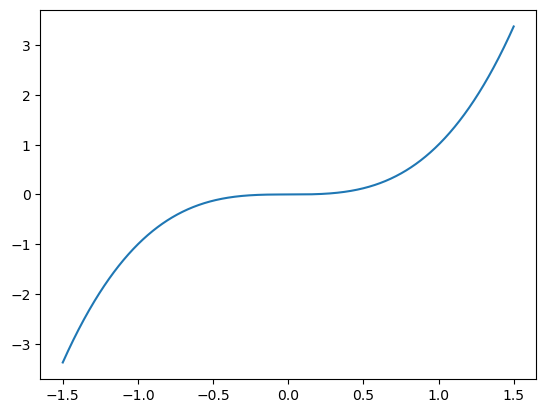

In [3]:
X = np.linspace(-1.5, 1.5, 1024)
y = X**3#np.cos(4.0*X) + np.exp(0.5*X**2) + np.random.normal(loc=0.0, scale=0.05)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

train_target_mu, train_target_sigma = y_train.mean(), y_train.std()
print(f'y_mean: {train_target_mu} | y_std: {train_target_sigma}')

train_x = torch.from_numpy(X_train).unsqueeze(-1).float()
test_x = torch.from_numpy(X_test).unsqueeze(-1).float()
train_y = torch.from_numpy(y_train).unsqueeze(-1).float()
test_y = torch.from_numpy(y_test).unsqueeze(-1).float()  

train_set = TensorDataset(train_x, train_y)
test_set = TensorDataset(test_x, test_y)

batch_size = 64
train_loader = DataLoader(train_set, batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size, shuffle=False)

plt.plot(X, y)